In [52]:
!pip install matplotlib

     |████████████████████████████████| 9.2 MB 10.8 MB/s eta 0:00:01
     |████████████████████████████████| 103 kB 15.4 MB/s eta 0:00:01
     |████████████████████████████████| 301 kB 10.9 MB/s eta 0:00:01
     |████████████████████████████████| 4.6 MB 10.8 MB/s eta 0:00:01
     |████████████████████████████████| 1.2 MB 10.9 MB/s eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [53]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [144]:
def quantize_pixel(pixel, n_colours):
    k = int(n_colours ** (1/3))
    factor = int(256 / k)
    return [int(pixel[0]/factor), int(pixel[1]/factor), int(pixel[2]/factor)]

def get_color_number_from_pixel(pixel, n_colours):
    k = int(n_colours ** (1/3))
    return k * k * pixel[0] + k * pixel[1] + pixel[2]

def convert_quantized_image_to_visualize(quantized_img, n_colours):
    k = int(n_colours ** (1/3))
    factor = int(256 / k)
    final_image = []
    for pixel in quantized_img.reshape(-1, 3):
        final_image.append([int(pixel[0] * factor), int(pixel[1] * factor), int(pixel[2] * factor)])
    final_image_np = np.asarray(final_image)
    final_image_np = final_image_np.reshape(quantized_img.shape)
    return final_image_np

def get_preprocessed_image(image, n_colours):
    # Blur the image
    blurred_image = cv2.blur(image, (3, 3))
    quantized_image = []
    for pixel in blurred_image.reshape(-1, 3):
        quantized_image.append(quantize_pixel(pixel, n_colours))
    quantized_image_np = np.asarray(quantized_image)
    quantized_image_np = quantized_image_np.reshape(image.shape)
    return quantized_image_np

def get_colour_mask_from_quantized_image(quantized_image, n_colours):
    color_mask = []
    for pixel in quantized_image.reshape(-1, 3):
        color_mask.append(get_color_number_from_pixel(pixel, n_colours))
    return np.asarray(color_mask)

def get_histo_masks(image):
    height, width, c = image.shape
    
    # Define the region to keep (central 75%)
    h_start = int(0.125 * height)
    h_end = int(0.875 * height)
    w_start = int(0.125 * width)
    w_end = int(0.875 * width)

    # Create a binary mask
    central_mask = np.zeros((height, width), dtype=np.uint8)
    central_mask[h_start : h_end, w_start : w_end] = 255
    peripheral_mask = ~central_mask

    # Plot the original image and the masked image
#     plt.subplot(1, 2, 1)
#     plt.title("Original Image")
#     plt.imshow(image, cmap='gray')

#     plt.subplot(1, 3, 2)
#     plt.title("Central Mask")
#     plt.imshow(central_mask, cmap='gray')

#     plt.subplot(1, 3, 3)
#     plt.title("Peripheral Image")
#     plt.imshow(peripheral_mask, cmap='gray')

#     plt.show()
    
    return central_mask, peripheral_mask

### The Three Measures

In [145]:
## Basic Color Histograms

def compare_histograms(img1, img2, bins):
    # Calculate histograms
    channel_bins = [bins, bins, bins]
    ranges = [0, 256, 0, 256, 0, 256]
    hist_img1 = cv2.calcHist([img1], [0, 1, 2], None, channel_bins, ranges)
    hist_img2 = cv2.calcHist([img2], [0, 1, 2], None, channel_bins, ranges)
    
    #Just to show
    plt.plot(hist_img1.ravel())
    plt.xlim([0,bins**3])
    plt.show()
    
    plt.plot(hist_img2.ravel())
    plt.xlim([0,bins**3])
    plt.show()

    # Normalize histograms
    cv2.normalize(hist_img1, hist_img1, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
    cv2.normalize(hist_img2, hist_img2, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

    # Distances
    corr = cv2.compareHist(hist_img1, hist_img2, cv2.HISTCMP_CORREL)
    l1_distance = cv2.compareHist(hist_img1, hist_img2, cv2.HISTCMP_BHATTACHARYYA)
    l2_distance = cv2.compareHist(hist_img1, hist_img2, cv2.HISTCMP_CHISQR)
    return np.abs(corr), l1_distance, l2_distance

In [150]:
### Split Histograms

def compare_split_histograms(img1, img2, bins):
    
    # Calculate histograms
    channel_bins = [bins, bins, bins]
    ranges = [0, 256, 0, 256, 0, 256]
    
    # Get masks
    central_mask_1, peripheral_mask_1 = get_histo_masks(img1)
    central_mask_2, peripheral_mask_2 = get_histo_masks(img2)
    
    # Compute Central Histograms
    central_hist_img1 = cv2.calcHist([img1], [0, 1, 2], central_mask_1, channel_bins, ranges)
    central_hist_img2 = cv2.calcHist([img2], [0, 1, 2], central_mask_2, channel_bins, ranges)
    
    # Compute Peripheral Histograms
    peripheral_hist_img1 = cv2.calcHist([img1], [0, 1, 2], peripheral_mask_1, channel_bins, ranges)
    peripheral_hist_img2 = cv2.calcHist([img2], [0, 1, 2], peripheral_mask_2, channel_bins, ranges)
    
    #Just to show
#     plt.plot(central_hist_img1.ravel())
#     plt.xlim([0,bins**3])
#     plt.show()
    
#     plt.plot(peripheral_hist_img1.ravel())
#     plt.xlim([0,bins**3])
#     plt.show()

    # Normalize histograms
    cv2.normalize(central_hist_img1, central_hist_img1, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
    cv2.normalize(central_hist_img2, central_hist_img2, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
    cv2.normalize(peripheral_hist_img1, peripheral_hist_img1, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
    cv2.normalize(peripheral_hist_img2, peripheral_hist_img2, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

    # Distances
    corr = cv2.compareHist(central_hist_img1, central_hist_img2, cv2.HISTCMP_CORREL) + cv2.compareHist(peripheral_hist_img1, peripheral_hist_img2, cv2.HISTCMP_CORREL)
    l1_distance = cv2.compareHist(central_hist_img1, central_hist_img2, cv2.HISTCMP_BHATTACHARYYA) + cv2.compareHist(peripheral_hist_img1, peripheral_hist_img2, cv2.HISTCMP_BHATTACHARYYA)
    l2_distance = cv2.compareHist(central_hist_img1, central_hist_img2, cv2.HISTCMP_CHISQR) + cv2.compareHist(peripheral_hist_img1, peripheral_hist_img2, cv2.HISTCMP_CHISQR)
    return np.abs(corr), l1_distance, l2_distance

In [151]:
### Color Coherence Vectors

def get_ccv_from_quantized_image(image, channel_bins, tau):
    n_colours = channel_bins ** 3
    quantized_image = get_preprocessed_image(image, n_colours)
    # Initialize coherence vector
    ccv_vector = []
    # Get color mask from quantized image
    colour_mask = get_colour_mask_from_quantized_image(quantized_image, n_colours)
    shaped_colour_mask = colour_mask.reshape(quantized_image.shape[0], quantized_image.shape[1])

    # Iterate over each discretized color
    for i in range(n_colours):
        # Extract pixels with the current color
        binary_mask = (shaped_colour_mask == i).astype(np.uint8)
        # Find connected components
        _, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, connectivity=4)
        # Initialize coherence pair
        alpha_j, beta_j = 0, 0
        # Iterate over connected components
        for j in range(1, stats.shape[0]):
            component_size = stats[j, cv2.CC_STAT_AREA]
            # Classify pixels as coherent or incoherent based on the size
            if component_size > tau:
                alpha_j += component_size
            else:
                beta_j += component_size
        # Add coherence pair to the vector
        ccv_vector.append(alpha_j)
        ccv_vector.append(beta_j)
    return np.asarray(ccv_vector)

def compare_ccvs(img1, img2, channel_bins, tau):
    ccv1 = get_ccv_from_quantized_image(img1, channel_bins, tau)
    ccv2 = get_ccv_from_quantized_image(img2, channel_bins, tau)
    l1 = np.sum(np.abs(ccv1 - ccv2))
    l2 = np.sqrt(np.sum((ccv1 - ccv2)**2))
    corr = np.corrcoef(ccv1, ccv2)[0, 1]
    return np.abs(corr), l1, l2

In [154]:
# Example usage
image1_path = '/home/dhruv/Projects/CBIR/data/823.jpg'
image2_path = '/home/dhruv/Projects/CBIR/data/image-882.jpg'

# Read images
img1 = cv2.imread(image1_path)
img2 = cv2.imread(image2_path)

# Preprocess images
channel_bins = 16
#n_colours = channel_bins ** 3

#correlation, l1, l2 = compare_histograms(img1, img2, channel_bins)
#correlation, l1, l2 = compare_split_histograms(img1, img2, channel_bins)
correlation, l1, l2 = compare_ccvs(img1, img2, channel_bins, 300)

print(f"Correlation Coefficient: {correlation}")
print(f"L1 Distance: {l1}")
print(f"L2 Distance: {l2}")

Correlation Coefficient: 0.14709872232463567
L1 Distance: 155368
L2 Distance: 15910.872760474203


In [8]:
import cv2
import numpy as np

def l1_distance(hist1, hist2):
    return np.sum(np.abs(hist1 - hist2))

def l2_distance(hist1, hist2):
    return np.sqrt(np.sum((hist1 - hist2)**2))

def compare_histograms(image1, image2):
    # Read images
    img1 = cv2.imread(image1)
    img2 = cv2.imread(image2)

    # Convert images to HSV color space
    hsv_img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2HSV)
    hsv_img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2HSV)

    # Calculate histograms
    hist_img1 = cv2.calcHist([hsv_img1], [0, 1], None, [180, 256], [0, 180, 0, 256])
    hist_img2 = cv2.calcHist([hsv_img2], [0, 1], None, [180, 256], [0, 180, 0, 256])

    # Normalize histograms
    cv2.normalize(hist_img1, hist_img1, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
    cv2.normalize(hist_img2, hist_img2, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

    # Correlation coefficient
    correlation_coefficient = cv2.compareHist(hist_img1, hist_img2, cv2.HISTCMP_CORREL)

    # L1 distance (Manhattan distance)
    l1_dist = l1_distance(hist_img1, hist_img2)

    # L2 distance (Euclidean distance)
    l2_dist = l2_distance(hist_img1, hist_img2)

    return correlation_coefficient, l1_dist, l2_dist

# Example usage
image1_path = '404.jpg'
image2_path = '410.jpg'

correlation, l1, l2 = compare_histograms(image1_path, image2_path)

print(f"Correlation Coefficient: {correlation}")
print(f"L1 Distance (Manhattan Distance): {l1}")
print(f"L2 Distance (Euclidean Distance): {l2}")


error: OpenCV(4.7.0) /io/opencv/modules/imgproc/src/color.cpp:182: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [ ]:
import os
import cv2
import numpy as np

def l1_distance(hist1, hist2):
    return np.sum(np.abs(hist1 - hist2))

def l2_distance(hist1, hist2):
    return np.sqrt(np.sum((hist1 - hist2)**2))

def compare_histograms(hist1, hist2, method):
    if method == "correlation":
        return cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)
    elif method == "l1":
        return l1_distance(hist1, hist2)
    elif method == "l2":
        return l2_distance(hist1, hist2)
    else:
        raise ValueError("Invalid method")

def load_images_from_folder(folder_path):
    images = []
    labels = []
    for subfolder_name in os.listdir(folder_path):
        subfolder_path = os.path.join(folder_path, subfolder_name)
        if os.path.isdir(subfolder_path):
            for filename in os.listdir(subfolder_path):
                img_path = os.path.join(subfolder_path, filename)
                images.append(cv2.imread(img_path))
                labels.append(subfolder_name)
    return images, labels

def process_query_image(query_image_path, training_images, training_labels, method="correlation"):
    # Read the query image
    query_image = cv2.imread(query_image_path)
    query_hsv = cv2.cvtColor(query_image, cv2.COLOR_BGR2HSV)
    query_hist = cv2.calcHist([query_hsv], [0, 1], None, [180, 256], [0, 180, 0, 256])
    cv2.normalize(query_hist, query_hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

    # Compare the query image with each training image
    similarities = []
    for i, training_image in enumerate(training_images):
        training_hsv = cv2.cvtColor(training_image, cv2.COLOR_BGR2HSV)
        training_hist = cv2.calcHist([training_hsv], [0, 1], None, [180, 256], [0, 180, 0, 256])
        cv2.normalize(training_hist, training_hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

        similarity = compare_histograms(query_hist, training_hist, method)
        similarities.append((similarity, training_labels[i]))

    # Sort the images based on similarity
    similarities.sort(reverse=True, key=lambda x: x[0])

    return similarities

def main():
    # Set your folder paths
    train_set_path = "/content/drive/MyDrive/Project_D/dataset/training_set"
    test_set_path = "/content/drive/MyDrive/Project_D/dataset/test_set"
    query_image_path = "404.jpg"

    # Load training images and labels
    training_images, training_labels = load_images_from_folder(train_set_path)

    # Process the query image
    similarities = process_query_image(query_image_path, training_images, training_labels)

    # Display the results
    print(f"Query image: {query_image_path}")
    print("Top 5 similar images in the training set:")
    for i in range(5):
        similarity, label = similarities[i]
        print(f"Similarity: {similarity:.4f}, Label: {label}")

if __name__ == "__main__":
    main()


Query image: 404.jpg
Top 5 similar images in the training set:
Similarity: 0.9953, Label: dinosaurs
Similarity: 0.9933, Label: dinosaurs
Similarity: 0.9912, Label: dinosaurs
Similarity: 0.9799, Label: dinosaurs
Similarity: 0.9628, Label: dinosaurs


Query image: 404.jpg
Top 5 similar images in the training set:
Similarity: 0.9953, Label: dinosaurs


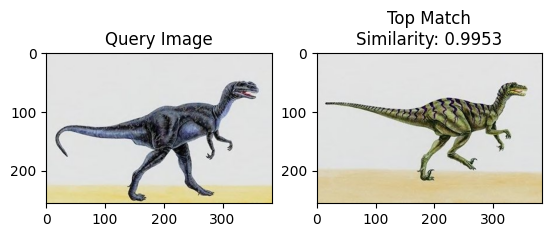

Similarity: 0.9933, Label: dinosaurs


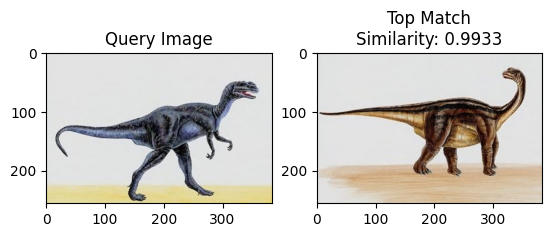

Similarity: 0.9912, Label: dinosaurs


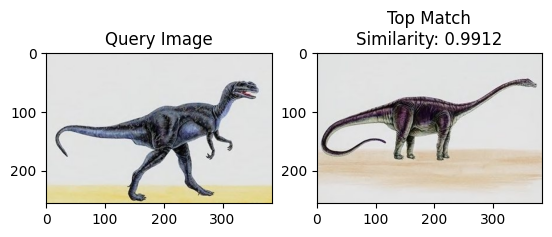

Similarity: 0.9799, Label: dinosaurs


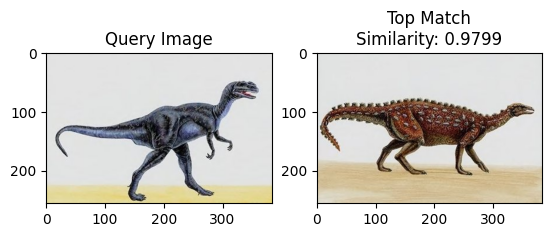

Similarity: 0.9628, Label: dinosaurs


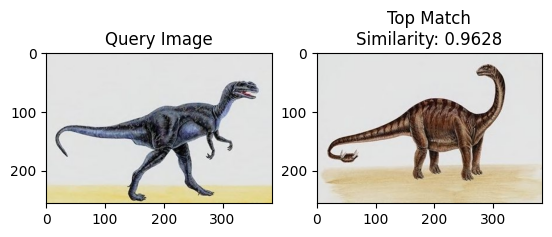

In [ ]:
import os
import cv2
import numpy as np

def l1_distance(hist1, hist2):
    return np.sum(np.abs(hist1 - hist2))

def l2_distance(hist1, hist2):
    return np.sqrt(np.sum((hist1 - hist2)**2))

def compare_histograms(hist1, hist2, method):
    if method == "correlation":
        return cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)
    elif method == "l1":
        return l1_distance(hist1, hist2)
    elif method == "l2":
        return l2_distance(hist1, hist2)
    else:
        raise ValueError("Invalid method")

def load_images_from_folder(folder_path):
    images = []
    labels = []
    for subfolder_name in os.listdir(folder_path):
        subfolder_path = os.path.join(folder_path, subfolder_name)
        if os.path.isdir(subfolder_path):
            for filename in os.listdir(subfolder_path):
                img_path = os.path.join(subfolder_path, filename)
                images.append(cv2.imread(img_path))
                labels.append(subfolder_name)
    return images, labels

def process_query_image(query_image_path, training_images, training_labels, method="correlation"):
    # Read the query image
    query_image = cv2.imread(query_image_path)
    query_hsv = cv2.cvtColor(query_image, cv2.COLOR_BGR2HSV)
    query_hist = cv2.calcHist([query_hsv], [0, 1], None, [180, 256], [0, 180, 0, 256])
    cv2.normalize(query_hist, query_hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

    # Compare the query image with each training image
    similarities = []
    for i, training_image in enumerate(training_images):
        training_hsv = cv2.cvtColor(training_image, cv2.COLOR_BGR2HSV)
        training_hist = cv2.calcHist([training_hsv], [0, 1], None, [180, 256], [0, 180, 0, 256])
        cv2.normalize(training_hist, training_hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

        similarity = compare_histograms(query_hist, training_hist, method)
        similarities.append((similarity, training_labels[i], training_image))

    # Sort the images based on similarity
    similarities.sort(reverse=True, key=lambda x: x[0])

    return similarities

def display_images(query_image, top_match_image, similarity_value):
    import matplotlib.pyplot as plt

    # Display query image
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(query_image, cv2.COLOR_BGR2RGB))
    plt.title("Query Image")

    # Display top match image
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(top_match_image, cv2.COLOR_BGR2RGB))
    plt.title(f"Top Match\nSimilarity: {similarity_value:.4f}")

    plt.show()

def main():
    # Mount Google Drive
    # drive.mount('/content/drive')

    # Set your folder paths
    train_set_path = "/content/drive/MyDrive/Project_D/dataset/training_set"
    query_image_path = "404.jpg"

    # Load training images and labels
    training_images, training_labels = load_images_from_folder(train_set_path)

    # Process the query image
    similarities = process_query_image(query_image_path, training_images, training_labels)

    # Display the results
    print(f"Query image: {query_image_path}")
    print("Top 5 similar images in the training set:")
    for i in range(5):
        similarity, label, top_match_image = similarities[i]
        print(f"Similarity: {similarity:.4f}, Label: {label}")

        # Display images
        display_images(cv2.imread(query_image_path), top_match_image, similarity)

if __name__ == "__main__":
    main()


Query image: 1.jpg

Top 5 similar images using L1:


<Figure size 1500x500 with 0 Axes>

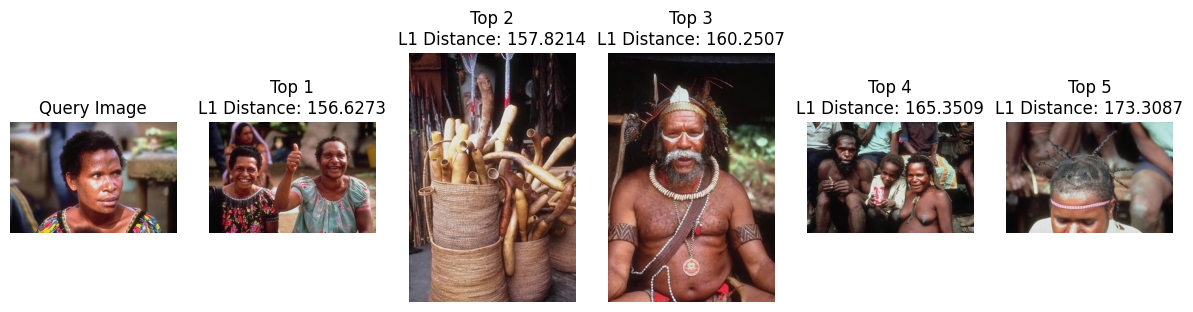


Top 5 similar images using L2:


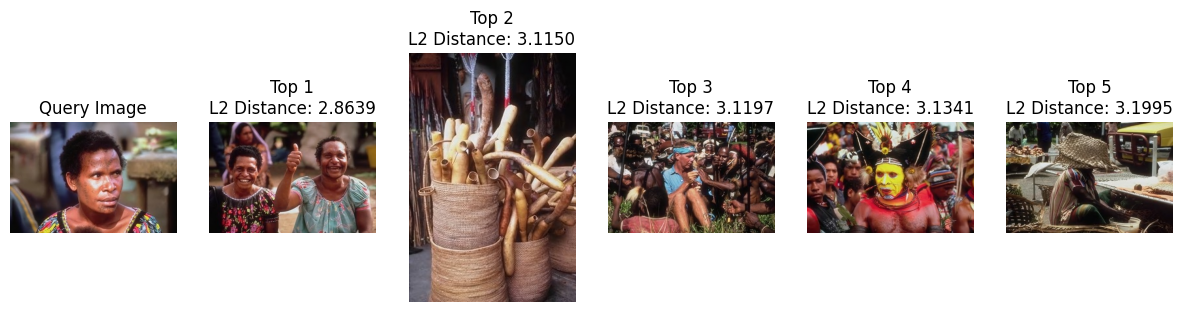


Top 5 similar images using Cor:


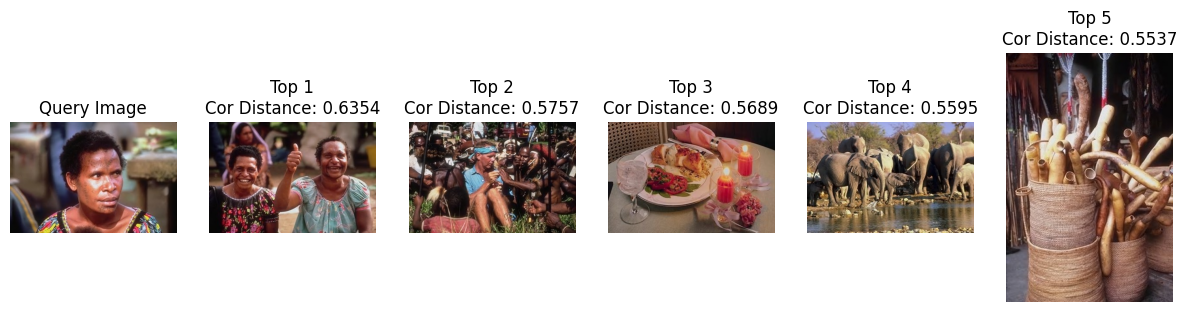

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def l1_distance(hist1, hist2):
    return np.sum(np.abs(hist1 - hist2))

def l2_distance(hist1, hist2):
    return np.sqrt(np.sum((hist1 - hist2)**2))

def compare_histograms(hist1, hist2, method):
    if method == "correlation":
        return cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)
    elif method == "l1":
        return l1_distance(hist1, hist2)
    elif method == "l2":
        return l2_distance(hist1, hist2)
    else:
        raise ValueError("Invalid method")

def load_images_from_folder(folder_path):
    images = []
    labels = []
    for subfolder_name in os.listdir(folder_path):
        subfolder_path = os.path.join(folder_path, subfolder_name)
        if os.path.isdir(subfolder_path):
            for filename in os.listdir(subfolder_path):
                img_path = os.path.join(subfolder_path, filename)
                images.append(cv2.imread(img_path))
                labels.append(subfolder_name)
    return images, labels

def process_query_image(query_image_path, training_images, training_labels, k=5):
    # Read the query image
    query_image = cv2.imread(query_image_path)
    query_hsv = cv2.cvtColor(query_image, cv2.COLOR_BGR2HSV)
    query_hist = cv2.calcHist([query_hsv], [0, 1], None, [180, 256], [0, 180, 0, 256])
    cv2.normalize(query_hist, query_hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

    # Compare the query image with each training image using different methods
    l1_distances = []
    l2_distances = []
    correlations = []

    for i, training_image in enumerate(training_images):
        training_hsv = cv2.cvtColor(training_image, cv2.COLOR_BGR2HSV)
        training_hist = cv2.calcHist([training_hsv], [0, 1], None, [180, 256], [0, 180, 0, 256])
        cv2.normalize(training_hist, training_hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

        # Calculate distances and correlations
        l1_dist = l1_distance(query_hist, training_hist)
        l2_dist = l2_distance(query_hist, training_hist)
        correlation = compare_histograms(query_hist, training_hist, "correlation")

        l1_distances.append((l1_dist, training_labels[i], training_image))
        l2_distances.append((l2_dist, training_labels[i], training_image))
        correlations.append((correlation, training_labels[i], training_image))

    # Sort the results based on distance or correlation
    l1_distances.sort(key=lambda x: x[0])
    l2_distances.sort(key=lambda x: x[0])
    correlations.sort(reverse=True, key=lambda x: x[0])

    return l1_distances[:k], l2_distances[:k], correlations[:k]

def display_results(query_image, results, method):
    print(f"\nTop {len(results)} similar images using {method}:")

    fig, axes = plt.subplots(1, len(results) + 1, figsize=(15, 5))

    # Display query image
    axes[0].imshow(cv2.cvtColor(query_image, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Query Image")
    axes[0].axis('off')

    for i, (distance, label, match_image) in enumerate(results):
        axes[i + 1].imshow(cv2.cvtColor(match_image, cv2.COLOR_BGR2RGB))
        axes[i + 1].set_title(f"Top {i + 1}\n{method.capitalize()} Distance: {distance:.4f}")
        axes[i + 1].axis('off')

    plt.show()


# def display_results(query_image, results, method):

#     print(f"\nTop {len(results)} similar images using {method}:")

#     fig, axes = plt.subplots(1, len(results), figsize=(15, 5))

#     for i, (distance, label, match_image) in enumerate(results):
#         axes[i].imshow(cv2.cvtColor(match_image, cv2.COLOR_BGR2RGB))
#         axes[i].set_title(f"Top {i + 1}\n{method.capitalize()} Distance: {distance:.4f}")
#         axes[i].axis('off')

#     plt.show()
    # print(f"\nTop {len(results)} similar images using {method}:")
    # for i, (distance, label, match_image) in enumerate(results):
    #     print(f"{i + 1}. Label: {label}, {method.capitalize()} D: {distance:.4f}")

    #     # Display match image using matplotlib
    #     plt.subplot(1, len(results), i + 1)
    #     plt.imshow(cv2.cvtColor(match_image, cv2.COLOR_BGR2RGB))
    #     plt.title(f"Top {i + 1}\n{method.capitalize()} D: {distance:.4f}")
    #     plt.axis('off')

    # plt.show()

def main():
    # Set your folder paths
    train_set_path = "/content/drive/MyDrive/Project_D/dataset/training_set"
    query_image_path = "1.jpg"

    # Load training images and labels
    training_images, training_labels = load_images_from_folder(train_set_path)

    # Process the query image for L1, L2, and correlation
    l1_results, l2_results, correlation_results = process_query_image(query_image_path, training_images, training_labels)

    # Display the results
    print(f"Query image: {query_image_path}")

    plt.figure(figsize=(15, 5))

    display_results(cv2.imread(query_image_path), l1_results, "L1")
    display_results(cv2.imread(query_image_path), l2_results, "L2")
    display_results(cv2.imread(query_image_path), correlation_results, "Cor")

if __name__ == "__main__":
    main()
